# CIC-UNSW-NB15 - Does the Graph Make the Model Better?

The other notebooks in this project attack malicious-traffic detection three different ways:

| Notebook | Approach | What it needs |
|----------|----------|---------------|
| [`baseline.ipynb`](baseline.ipynb) | **Statistical baselining** - per-feature robust Z-scores over `(protocol, port, hour, day)` groups | no labels, no model |
| [`gds.ipynb`](gds.ipynb) | **Unsupervised graph similarity** - FastRP embeddings + KNN against known IoCs | no labels |
| **this notebook** | **Supervised ML** - a classifier trained on labelled flows | labels at train time |

This notebook isolates one question: **do graph-derived features actually improve a supervised classifier, or are the per-flow statistics enough on their own?**

To answer it fairly we train the **same** model (`RandomForestClassifier`) **twice** on the **same** train/test split, changing only the feature set:

- **Model A - flow-only.** The ~28 per-flow CICFlowMeter statistics already stored on each `:Flow` (duration, byte/packet rates, IAT timing, packet-size profile, TCP flags). This is what a classical flow-based NIDS sees: every flow scored in isolation.
- **Model B - flow + graph.** The identical flow statistics **plus** structural features describing the *role each endpoint plays in the host-communication graph* - degree (fan-out / fan-in), PageRank, betweenness, and a 16-dimensional FastRP embedding - computed with **Neo4j GDS** over the `(:Host)-[:CONNECTED_TO]->(:Host)` projection and attached to both the source and destination host of every flow.

A single flow can lie about itself; its host's position in the communication graph is much harder to fake. That structural context is the signal we are testing for.

> **Everything comes from Neo4j.** The flow features, the labels, and the graph features are all read from the graph built by [`loader.ipynb`](loader.ipynb). No external feature store, no CSV.

## Setup

Connect through the `Neo4jAnalysis` helper, confirm GDS is reachable, and fix every random seed so the whole notebook is reproducible.

In [1]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
from IPython.display import display

from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    f1_score,
)

from neo4j_analysis import Neo4jAnalysis

warnings.filterwarnings("ignore")
load_dotenv()

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

analysis = Neo4jAnalysis(
    os.getenv("NEO4J_URI"),
    os.getenv("NEO4J_USERNAME"),
    os.getenv("NEO4J_PASSWORD"),
    os.getenv("NEO4J_DATABASE"),
)
print("connection ok:", analysis.verify_connection())

# GDS is reachable even though Aura Graph Analytics reports no version string.
try:
    n = analysis.run_query_single(
        "CALL gds.graph.list() YIELD graphName RETURN count(*) AS n"
    )["n"]
    print(f"GDS reachable - {n} in-memory graph(s) currently projected")
except Exception as e:
    print("GDS not reachable:", str(e)[:160])

RENDER_DIR = os.getenv("RENDER_DIR", "renderings")
os.makedirs(RENDER_DIR, exist_ok=True)

connection ok: True
GDS reachable - 1 in-memory graph(s) currently projected


## Configuration

Two knobs control the experiment. Sampling is **deterministic** - we keep a flow whenever `f.key % BENIGN_MODULO == 0`, so re-running the notebook pulls the exact same rows.

- `BENIGN_MODULO` - keep 1 benign flow in this many. The graph holds **3.45M benign** vs **~90k malicious** flows; pulling all benign would be slow and pointlessly memory-heavy for a demo, so we down-sample benign while keeping **every** malicious flow. `23` yields ~150k benign, a tractable ~1.7 : 1 benign : malicious mix that still lets PR-AUC / recall tell the real story.
- `FLOW_FEATURES` - the per-flow CICFlowMeter statistics that make up Model A and the shared core of Model B. This single list drives the pull, both models, and the importance plots.

In [2]:
BENIGN_MODULO = 23  # keep 1-in-N benign flows (deterministic via f.key); all malicious kept

# Per-flow statistical features stored on each :Flow node by loader.ipynb.
# A representative cross-section of the 76 CICFlowMeter columns covering the
# axes a flow-based NIDS relies on:
FLOW_FEATURES = [
    # volume / rate
    "flowDuration", "flowBytesPerSec", "flowPacketsPerSec",
    "fwdPacketsPerSec", "bwdPacketsPerSec",
    "totalFwdPacket", "totalBwdPackets",
    "totalLengthOfFwdPacket", "totalLengthOfBwdPacket",
    # timing / beaconing
    "flowIatMean", "flowIatStd", "fwdIatMean", "bwdIatMean", "idleMean",
    # packet-size profile
    "packetLengthMean", "packetLengthStd", "averagePacketSize",
    "fwdPacketLengthMean", "bwdPacketLengthMean", "downUpRatio",
    # TCP flags (scan / reset tells)
    "synFlagCount", "ackFlagCount", "rstFlagCount", "finFlagCount", "pshFlagCount",
    # connection-setup fingerprints
    "fwdInitWinBytes", "bwdInitWinBytes", "fwdSegSizeMin",
]
print(f"{len(FLOW_FEATURES)} per-flow features")

28 per-flow features


## Step 1 - Pull the labelled flow dataset

First we ask the graph **which source hosts ever send an attack**. This list does double duty: it drives a *stratified* sample (next cell) and it defines the honest stress test in Step 7.

In [3]:
attacker_hosts = analysis.run_query_df("""
    MATCH (h:Host)-[:SENDS]->(f:Flow)
    WITH h.ip AS ip,
         sum(CASE WHEN f.label <> 'Benign' THEN 1 ELSE 0 END) AS mal,
         count(f) AS total
    WHERE mal > 0
    RETURN ip, mal AS attackFlows, total AS totalFlows,
           toFloat(mal) / total AS attackRate
    ORDER BY attackFlows DESC
""")
attackers = attacker_hosts["ip"].tolist()
display(attacker_hosts)
print("attacker source hosts:", attackers)

,ip,attackFlows,totalFlows,attackRate
0,175.45.176.0,22939,35269,0.650401
1,175.45.176.1,22927,36985,0.619900
2,175.45.176.3,22461,38815,0.578668
3,175.45.176.2,21256,34868,0.609613


attacker source hosts: ['175.45.176.0', '175.45.176.1', '175.45.176.3', '175.45.176.2']


Only four hosts (`175.45.176.0-3`) ever attack, and crucially they are **~60% malicious / ~40% benign** - they send plenty of ordinary traffic too. Every other host is benign-only.

That shapes the sample. We pull one row per flow - its per-flow statistics, the **source** and **destination** host IPs (the join keys for the graph features), and the ground-truth `label` - but sample **deterministically and by stratum**:

- **every malicious flow** (only ~90k, the scarce class),
- **every flow from an attacker host** (so their benign traffic is kept in full - this is what makes Step 7 a real test rather than a giveaway),
- **1-in-`BENIGN_MODULO`** of the benign traffic from all the benign-only hosts (the 3.4M-flow bulk we down-sample).

The target is binary - `isMalicious = label <> 'Benign'`.

In [4]:
_feat_return = ",\n           ".join(f"f.{c} AS {c}" for c in FLOW_FEATURES)

flows = analysis.run_query_to_df(
    f"""
    MATCH (src:Host)-[:SENDS]->(f:Flow)-[:TO]->(dst:Host)
    WHERE f.label <> 'Benign'          // keep every attack
       OR src.ip IN $attackers         // keep ALL attacker-host traffic (incl. benign)
       OR f.key % {BENIGN_MODULO} = 0  // down-sample the benign-only hosts
    RETURN f.key   AS key,
           src.ip  AS srcIp,
           dst.ip  AS dstIp,
           f.label AS label,
           {_feat_return}
    """,
    params={"attackers": attackers},
)

# Binary target; keep the fine-grained label for the per-category breakdown later.
flows["isMalicious"] = (flows["label"] != "Benign").astype(int)

# CICFlowMeter emits +/-Inf for rate columns on zero-duration flows; make them NaN so
# the median imputer in the pipeline can handle them uniformly.
flows[FLOW_FEATURES] = flows[FLOW_FEATURES].replace([np.inf, -np.inf], np.nan)

print(f"pulled {len(flows):,} flows")
print(f"malicious rate: {flows['isMalicious'].mean():.1%}")
display(flows["label"].value_counts())

pulled 293,501 flows
malicious rate: 30.5%


label
Benign            203918
Exploits           30951
Fuzzers            29613
Reconnaissance     16735
Generic             4632
DoS                 4467
Shellcode           2102
Backdoor             452
Analysis             385
Worms                246
Name: count, dtype: int64

### Why this is a fair test, not a leak

A natural worry with host-level features is that the model just memorises *which host is the attacker*. The graph says otherwise - look at the per-source-host label mix **in the sampled data**:

In [5]:
host_mix = (
    flows.groupby("srcIp")["isMalicious"]
    .agg(flows="count", malicious="sum")
    .assign(malicious_rate=lambda d: d["malicious"] / d["flows"])
    .sort_values("malicious", ascending=False)
)
display(host_mix.head(8))

atk_benign_rate = 1 - host_mix.loc[attackers, "malicious"].sum() / host_mix.loc[attackers, "flows"].sum()
print(f"benign traffic is still {atk_benign_rate:.0%} of the attacker hosts' flows")

,flows,malicious,malicious_rate
srcIp,,,
175.45.176.0,35269,22939,0.650401
175.45.176.1,36985,22927,0.619900
175.45.176.3,38815,22461,0.578668
175.45.176.2,34868,21256,0.609613
10.40.182.1,1,0,0.000000
59.166.0.0,14288,0,0.000000
149.171.126.8,530,0,0.000000
149.171.126.9,542,0,0.000000


benign traffic is still 39% of the attacker hosts' flows


Because we kept their traffic in full, the four attacker hosts (`175.45.176.0-3`) still show a roughly **40% benign** mix in the sample, while every other host is benign-only. So source-host identity **cannot** decide the label on its own: the model still has to separate an attacker's benign sessions from its attacks. Graph features supply a useful *prior* ("this endpoint behaves like a hub / scanner"), not the answer. We return to this in **Step 7**, where we score the attacker-host flows in isolation - the subset where the graph prior is constant and only the flow statistics can break the tie.

We also deliberately **exclude the `attackFlows` edge weight** from every GDS projection below: it is derived from the label and would leak the target straight into the features. The graph features use only **topology** and label-free **volume** (`flows`, `bytes`).

## Step 2 - Compute graph features with GDS

The host-communication graph is tiny - ~40 hosts, ~290 `CONNECTED_TO` edges - but it encodes exactly the structure a single flow can't: who fans out to many peers (scanners / attackers), who is a central hub, who bridges subnets.

We project `(:Host)-[:CONNECTED_TO]->(:Host)` once (weighted by the label-free `flows` / `bytes` properties) and run four GDS algorithms, streaming each result back keyed by host IP:

| Feature | Algorithm | Captures |
|---------|-----------|----------|
| `peersOut` | `gds.degree` (NATURAL) | how many distinct hosts this one *contacts* - fan-out / scanning |
| `peersIn` | `gds.degree` (REVERSE) | how many distinct hosts *contact* it - exposure / popularity |
| `pageRank` | `gds.pageRank` (weighted by `flows`) | flow-weighted influence in the comms graph |
| `betweenness` | `gds.betweenness` | bridging - sitting on paths between other hosts |
| `emb0..emb15` | `gds.fastRP` (seeded, weighted by `flows`) | a dense topological fingerprint of the host's neighbourhood |

In [6]:
GRAPH_NAME = "host-ml"

# Drop any stale projection from a previous run.
analysis.run_query(f"""
    CALL gds.graph.list() YIELD graphName
    WHERE graphName = '{GRAPH_NAME}'
    CALL gds.graph.drop(graphName) YIELD graphName AS dropped
    RETURN dropped
""")

# Project the host graph. NOTE: we project only the label-free weights (flows, bytes).
# attackFlows is intentionally excluded - it is derived from the label and would leak.
proj = analysis.run_query_single(f"""
    CALL gds.graph.project(
      '{GRAPH_NAME}',
      'Host',
      'CONNECTED_TO',
      {{ relationshipProperties: ['flows', 'bytes'], memory: '2GB' }}
    )
    YIELD graphName, nodeCount, relationshipCount
    RETURN graphName, nodeCount, relationshipCount
""")
print(f"projected '{proj['graphName']}': {proj['nodeCount']} hosts, "
      f"{proj['relationshipCount']} CONNECTED_TO edges")

projected 'host-ml': 43 hosts, 293 CONNECTED_TO edges


In [7]:
FASTRP_DIM = 16

# --- centrality / degree -------------------------------------------------------------
peers_out = analysis.run_query_df(f"""
    CALL gds.degree.stream('{GRAPH_NAME}', {{ orientation: 'NATURAL' }})
    YIELD nodeId, score
    RETURN gds.util.asNode(nodeId).ip AS ip, score AS peersOut
""")
peers_in = analysis.run_query_df(f"""
    CALL gds.degree.stream('{GRAPH_NAME}', {{ orientation: 'REVERSE' }})
    YIELD nodeId, score
    RETURN gds.util.asNode(nodeId).ip AS ip, score AS peersIn
""")
pagerank = analysis.run_query_df(f"""
    CALL gds.pageRank.stream('{GRAPH_NAME}', {{ relationshipWeightProperty: 'flows' }})
    YIELD nodeId, score
    RETURN gds.util.asNode(nodeId).ip AS ip, score AS pageRank
""")
betweenness = analysis.run_query_df(f"""
    CALL gds.betweenness.stream('{GRAPH_NAME}')
    YIELD nodeId, score
    RETURN gds.util.asNode(nodeId).ip AS ip, score AS betweenness
""")

# --- FastRP structural embedding (seeded for reproducibility) ------------------------
emb = analysis.run_query_df(f"""
    CALL gds.fastRP.stream('{GRAPH_NAME}', {{
      embeddingDimension: {FASTRP_DIM},
      randomSeed: {RANDOM_STATE},
      relationshipWeightProperty: 'flows'
    }})
    YIELD nodeId, embedding
    RETURN gds.util.asNode(nodeId).ip AS ip, embedding
""")
emb_cols = [f"emb{i}" for i in range(FASTRP_DIM)]
emb[emb_cols] = pd.DataFrame(emb["embedding"].tolist(), index=emb.index)
emb = emb.drop(columns="embedding")

# --- one row per host, all structural features --------------------------------------
host_features = (
    peers_out.merge(peers_in, on="ip")
    .merge(pagerank, on="ip")
    .merge(betweenness, on="ip")
    .merge(emb, on="ip")
)
GRAPH_FEATURES = ["peersOut", "peersIn", "pageRank", "betweenness"] + emb_cols
print(f"{len(host_features)} hosts x {len(GRAPH_FEATURES)} structural features")
display(host_features[["ip", "peersOut", "peersIn", "pageRank", "betweenness"]]
        .sort_values("peersOut", ascending=False).head(8))

43 hosts x 20 structural features


,ip,peersOut,peersIn,pageRank,betweenness
0,175.45.176.2,10.0,11.0,1.657617,28.5
25,149.171.126.4,10.0,10.0,0.975445,9.0
27,149.171.126.9,10.0,10.0,0.944355,9.0
1,175.45.176.0,10.0,11.0,1.685432,28.5
28,149.171.126.2,10.0,10.0,0.975285,9.0
29,149.171.126.0,10.0,10.0,0.971961,9.0
30,149.171.126.3,10.0,10.0,0.975463,9.0
31,149.171.126.5,10.0,10.0,0.971495,9.0


### The attacker hosts stand out structurally

Plotting two of the GDS features - fan-out (`peersOut`) against flow-weighted `pageRank` - already separates the attacker hosts from the benign population, **before any flow statistics are involved**. The colour here is purely illustrative (derived from the labels for the plot); it is *not* a model feature.

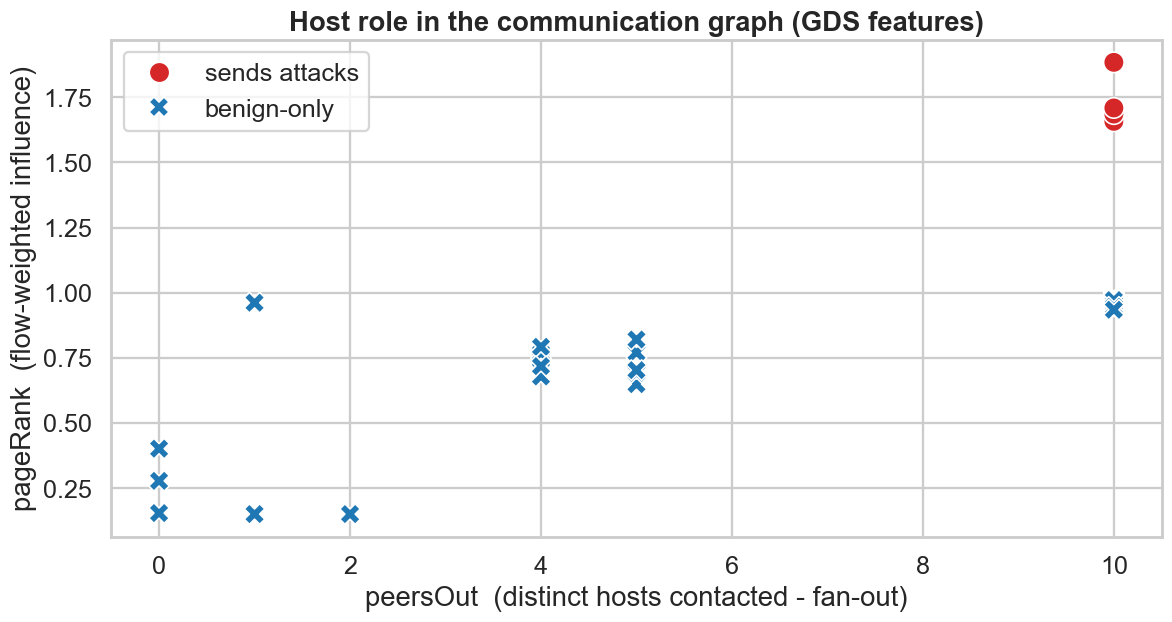

In [8]:
plot_df = host_features.copy()
plot_df["role"] = np.where(plot_df["ip"].isin(attackers), "sends attacks", "benign-only")

plt.figure(figsize=(11, 6))
sns.scatterplot(
    data=plot_df, x="peersOut", y="pageRank", hue="role",
    style="role", s=180, palette={"sends attacks": "#d62728", "benign-only": "#1f77b4"},
)
plt.title("Host role in the communication graph (GDS features)")
plt.xlabel("peersOut  (distinct hosts contacted - fan-out)")
plt.ylabel("pageRank  (flow-weighted influence)")
plt.legend(title="")
plt.tight_layout()
plt.show()

## Step 3 - Assemble the two feature matrices

Each flow inherits the structural features of **both** its endpoints: the source host's features get a `src_` prefix, the destination host's a `dst_` prefix. A flow from a high-fan-out source to a normally-quiet destination looks very different, structurally, from ordinary chatter.

- `X_base` = `FLOW_FEATURES` only ........... (Model A)
- `X_graph` = `FLOW_FEATURES` + `src_*` + `dst_*` graph features (Model B)

In [9]:
# Attach source-host and destination-host structural features.
src_gf = host_features.add_prefix("src_").rename(columns={"src_ip": "srcIp"})
dst_gf = host_features.add_prefix("dst_").rename(columns={"dst_ip": "dstIp"})

data = flows.merge(src_gf, on="srcIp", how="left").merge(dst_gf, on="dstIp", how="left")

src_graph_cols = [f"src_{c}" for c in GRAPH_FEATURES]
dst_graph_cols = [f"dst_{c}" for c in GRAPH_FEATURES]
graph_cols = src_graph_cols + dst_graph_cols

base_cols = FLOW_FEATURES                 # Model A
graph_model_cols = FLOW_FEATURES + graph_cols  # Model B

y = data["isMalicious"].values
print(f"Model A (flow-only):   {len(base_cols)} features")
print(f"Model B (flow+graph):  {len(graph_model_cols)} features  "
      f"(+{len(graph_cols)} structural)")
print(f"rows: {len(data):,}  |  malicious: {y.mean():.1%}")

Model A (flow-only):   28 features
Model B (flow+graph):  68 features  (+40 structural)
rows: 293,501  |  malicious: 30.5%


## Step 4 - Train both models on one shared split

We make a single stratified 70/30 split and train the **same** `RandomForestClassifier` configuration on each feature set, so any difference in performance comes purely from the features. A median `SimpleImputer` fills the NaNs (zero-duration rate columns, plus any host that had no projected edges). `class_weight="balanced_subsample"` keeps the minority malicious class from being swamped.

In [10]:
idx = np.arange(len(data))
train_idx, test_idx = train_test_split(
    idx, test_size=0.30, stratify=y, random_state=RANDOM_STATE
)
y_train, y_test = y[train_idx], y[test_idx]


def make_model():
    return Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("clf", RandomForestClassifier(
            n_estimators=200,
            max_depth=None,
            min_samples_leaf=2,
            class_weight="balanced_subsample",
            n_jobs=-1,
            random_state=RANDOM_STATE,
        )),
    ])


def fit_eval(name, cols):
    X = data[cols].values
    model = make_model().fit(X[train_idx], y_train)
    proba = model.predict_proba(X[test_idx])[:, 1]
    pred = (proba >= 0.5).astype(int)
    metrics = {
        "name": name,
        "n_features": len(cols),
        "roc_auc": roc_auc_score(y_test, proba),
        "pr_auc": average_precision_score(y_test, proba),
        "f1": f1_score(y_test, pred),
    }
    return model, proba, pred, metrics


model_a, proba_a, pred_a, m_a = fit_eval("flow-only", base_cols)
model_b, proba_b, pred_b, m_b = fit_eval("flow+graph", graph_model_cols)
print("trained both models")

trained both models


## Step 5 - Contrast the two models

Three threshold-independent / threshold-fixed views of the same held-out test set:

- **ROC-AUC** - ranking quality across all thresholds.
- **PR-AUC (average precision)** - the honest metric under class imbalance; how well malicious flows are ranked above benign.
- **F1** at the default 0.5 threshold - the operating-point trade-off between precision and recall.

,n_features,roc_auc,pr_auc,f1,pr_auc_gain
name,,,,,
flow-only,28,0.9528,0.8841,0.8092,+0.0000
flow+graph,68,0.9638,0.9047,0.8400,+0.0206


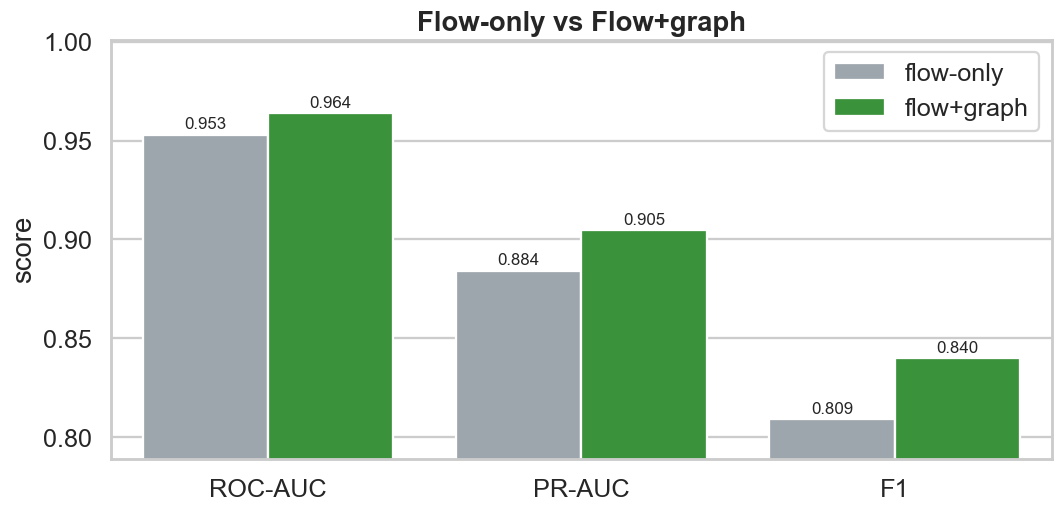

In [11]:
summary = pd.DataFrame([m_a, m_b]).set_index("name")[
    ["n_features", "roc_auc", "pr_auc", "f1"]
]
summary["pr_auc_gain"] = summary["pr_auc"] - summary.loc["flow-only", "pr_auc"]
display(summary.style.format(
    {"roc_auc": "{:.4f}", "pr_auc": "{:.4f}", "f1": "{:.4f}", "pr_auc_gain": "{:+.4f}"}
))

fig, ax = plt.subplots(figsize=(10, 5))
metrics_long = (
    summary[["roc_auc", "pr_auc", "f1"]]
    .rename(columns={"roc_auc": "ROC-AUC", "pr_auc": "PR-AUC", "f1": "F1"})
    .reset_index()
    .melt(id_vars="name", var_name="metric", value_name="score")
)
sns.barplot(data=metrics_long, x="metric", y="score", hue="name",
            palette={"flow-only": "#9aa7b0", "flow+graph": "#2ca02c"}, ax=ax)
ax.set_ylim(min(0.8, metrics_long["score"].min() - 0.02), 1.001)
ax.set_title("Flow-only vs Flow+graph")
ax.set_xlabel(""); ax.set_ylabel("score"); ax.legend(title="")
for c in ax.containers:
    ax.bar_label(c, fmt="%.3f", padding=2, fontsize=11)
plt.tight_layout(); plt.show()

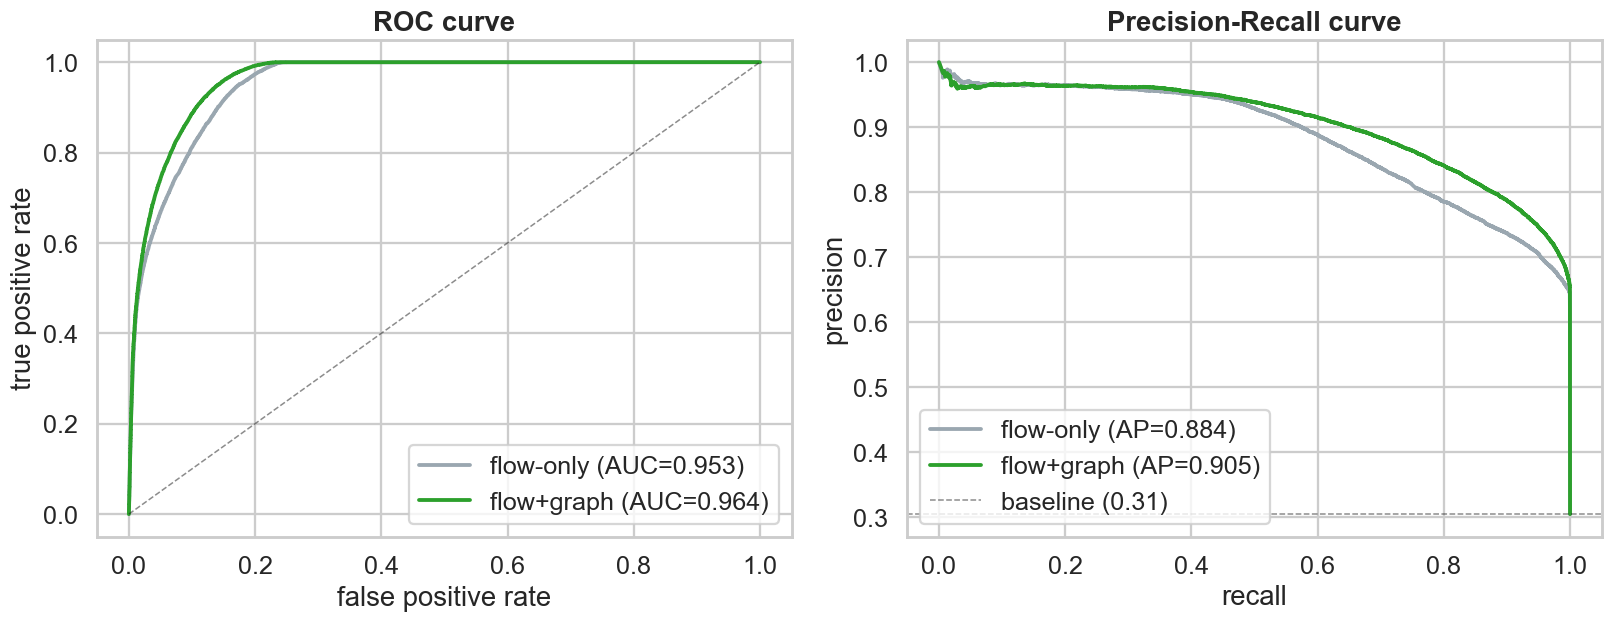

In [12]:
# ROC and Precision-Recall curves, overlaid.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

for proba, label, color in [(proba_a, "flow-only", "#9aa7b0"),
                            (proba_b, "flow+graph", "#2ca02c")]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    ax1.plot(fpr, tpr, color=color, lw=2.5,
             label=f"{label} (AUC={roc_auc_score(y_test, proba):.3f})")
    prec, rec, _ = precision_recall_curve(y_test, proba)
    ax2.plot(rec, prec, color=color, lw=2.5,
             label=f"{label} (AP={average_precision_score(y_test, proba):.3f})")

ax1.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5)
ax1.set_title("ROC curve"); ax1.set_xlabel("false positive rate"); ax1.set_ylabel("true positive rate")
ax1.legend(loc="lower right")
ax2.axhline(y_test.mean(), color="k", ls="--", lw=1, alpha=0.5, label=f"baseline ({y_test.mean():.2f})")
ax2.set_title("Precision-Recall curve"); ax2.set_xlabel("recall"); ax2.set_ylabel("precision")
ax2.legend(loc="lower left")
plt.tight_layout(); plt.show()

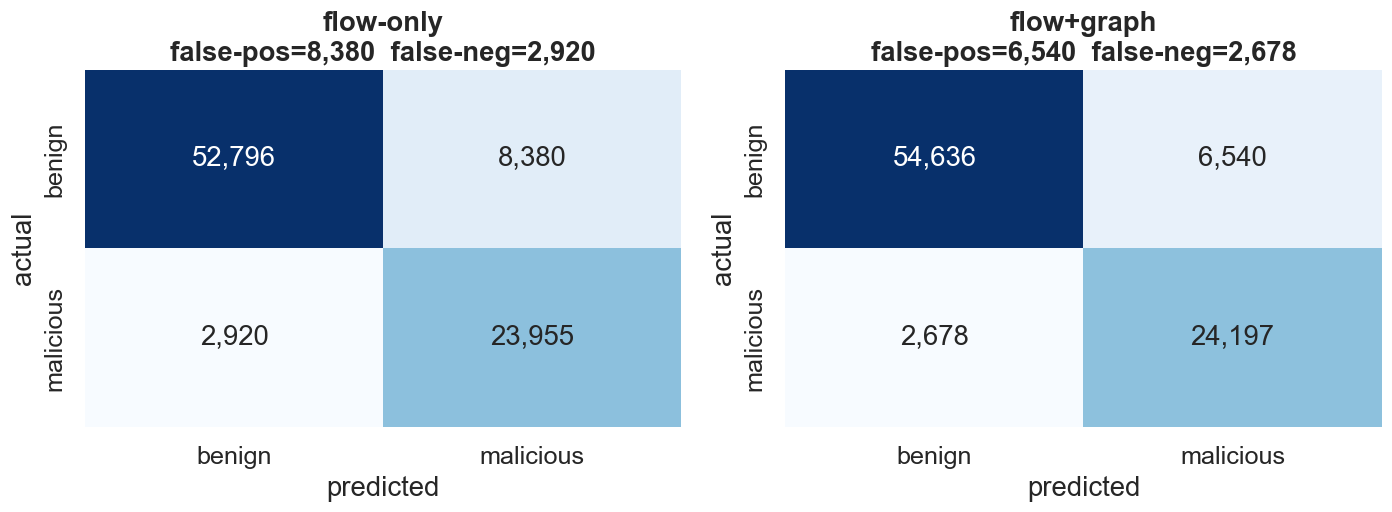

=== flow-only ===
              precision    recall  f1-score   support

      benign     0.9476    0.8630    0.9033     61176
   malicious     0.7408    0.8913    0.8092     26875

    accuracy                         0.8717     88051
   macro avg     0.8442    0.8772    0.8562     88051
weighted avg     0.8845    0.8717    0.8746     88051

=== flow+graph ===
              precision    recall  f1-score   support

      benign     0.9533    0.8931    0.9222     61176
   malicious     0.7872    0.9004    0.8400     26875

    accuracy                         0.8953     88051
   macro avg     0.8703    0.8967    0.8811     88051
weighted avg     0.9026    0.8953    0.8971     88051



In [13]:
# Confusion matrices at the 0.5 threshold.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, pred, m in [(axes[0], pred_a, m_a), (axes[1], pred_b, m_b)]:
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["benign", "malicious"], yticklabels=["benign", "malicious"])
    fp, fn = cm[0, 1], cm[1, 0]
    ax.set_title(f"{m['name']}\nfalse-pos={fp:,}  false-neg={fn:,}")
    ax.set_xlabel("predicted"); ax.set_ylabel("actual")
plt.tight_layout(); plt.show()

print("=== flow-only ===")
print(classification_report(y_test, pred_a, target_names=["benign", "malicious"], digits=4))
print("=== flow+graph ===")
print(classification_report(y_test, pred_b, target_names=["benign", "malicious"], digits=4))

## Step 6 - Where does the graph model get its signal?

Random-forest impurity importances, with graph features highlighted. We also collapse them into a single number: **what share of total importance the structural features carry** in Model B.

structural features carry 68.2% of total importance in Model B (40 of 68 features)


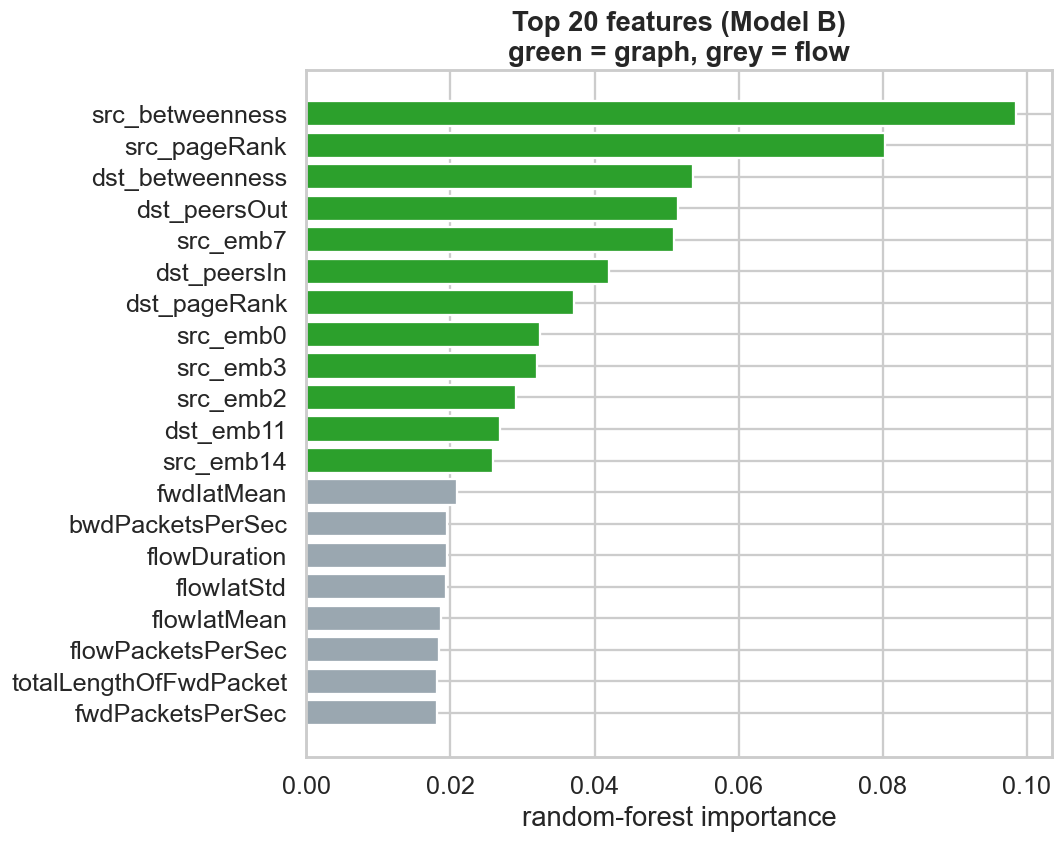

In [14]:
importances = pd.Series(
    model_b.named_steps["clf"].feature_importances_, index=graph_model_cols
).sort_values(ascending=False)

is_graph = importances.index.isin(graph_cols)
graph_share = importances[is_graph].sum()
print(f"structural features carry {graph_share:.1%} of total importance in Model B "
      f"({len(graph_cols)} of {len(graph_model_cols)} features)")

top = importances.head(20)
colors = ["#2ca02c" if f in graph_cols else "#9aa7b0" for f in top.index]
plt.figure(figsize=(10, 8))
plt.barh(top.index[::-1], top.values[::-1], color=colors[::-1])
plt.title("Top 20 features (Model B)\ngreen = graph, grey = flow")
plt.xlabel("random-forest importance")
plt.tight_layout(); plt.show()

## Step 7 - The honest stress test: attacker-host flows only

The headline numbers can flatter the graph model, because most benign traffic comes from hosts that *never* attack - so a "this endpoint looks like an attacker" prior is right most of the time. The real test is the subset where that prior is **useless**: flows whose source is one of the four attacker hosts. Here every `src_*` graph feature is (nearly) constant, so the model can only separate benign from malicious using **flow statistics and the destination's role**.

If the graph model still beat the flow-only model by a wide margin on this subset, we'd suspect host-identity leakage. If the two converge here, it confirms the graph features are contributing a legitimate *prior* on the easy traffic while the flow features do the hard within-host discrimination.

In [15]:
# Restrict the test set to flows originating from the attacker hosts.
test_src = data.iloc[test_idx]["srcIp"].values
mask = np.isin(test_src, attackers)
print(f"attacker-host flows in test set: {mask.sum():,} "
      f"({y_test[mask].mean():.1%} malicious)")

hard = pd.DataFrame({
    "model": ["flow-only", "flow+graph"],
    "roc_auc": [roc_auc_score(y_test[mask], proba_a[mask]),
                roc_auc_score(y_test[mask], proba_b[mask])],
    "pr_auc": [average_precision_score(y_test[mask], proba_a[mask]),
               average_precision_score(y_test[mask], proba_b[mask])],
    "f1": [f1_score(y_test[mask], pred_a[mask]),
           f1_score(y_test[mask], pred_b[mask])],
}).set_index("model")
display(hard.style.format("{:.4f}"))

attacker-host flows in test set: 43,869 (61.3% malicious)


,roc_auc,pr_auc,f1
model,,,
flow-only,0.8363,0.8873,0.8133
flow+graph,0.8697,0.9047,0.8400


## Step 8 - Which attack families benefit most?

Recall per ground-truth attack category, for both models. Stealthy, low-volume families (`Worms`, `Backdoor`, `Analysis`, `Shellcode`) - the ones a per-flow detector struggles with in [`baseline.ipynb`](baseline.ipynb) - are where structural context tends to add the most.

,flows,recall_flow_only,recall_flow_graph
label,,,
Exploits,9300,0.952,0.954
Fuzzers,8883,0.780,0.804
Reconnaissance,5080,0.959,0.955
Generic,1365,0.969,0.968
DoS,1322,0.933,0.946
Shellcode,598,0.871,0.895
Backdoor,147,0.925,0.986
Analysis,108,0.167,0.139
Worms,72,0.986,0.903


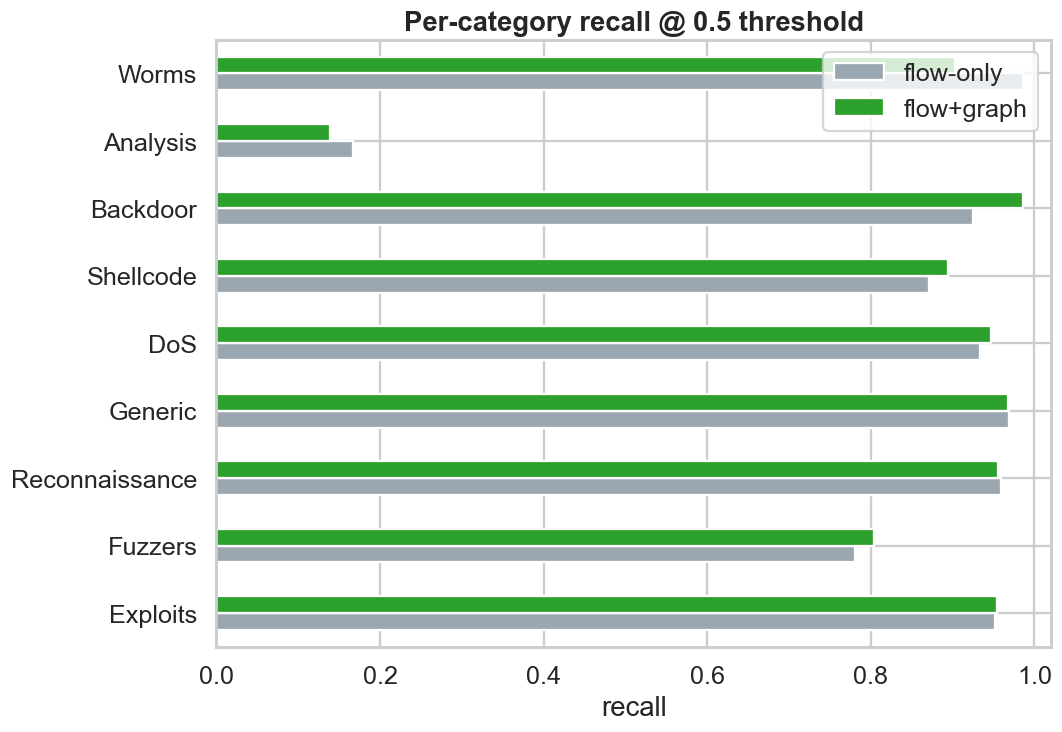

In [16]:
test_labels = data.iloc[test_idx]["label"].values
mal = test_labels != "Benign"

per_cat = (
    pd.DataFrame({"label": test_labels[mal],
                  "flow-only": pred_a[mal], "flow+graph": pred_b[mal]})
    .groupby("label")
    .agg(flows=("flow-only", "size"),
         recall_flow_only=("flow-only", "mean"),
         recall_flow_graph=("flow+graph", "mean"))
    .sort_values("flows", ascending=False)
)
display(per_cat.style.format(
    {"recall_flow_only": "{:.3f}", "recall_flow_graph": "{:.3f}"}))

ax = per_cat[["recall_flow_only", "recall_flow_graph"]].rename(
    columns={"recall_flow_only": "flow-only", "recall_flow_graph": "flow+graph"}
).plot.barh(figsize=(10, 7), color={"flow-only": "#9aa7b0", "flow+graph": "#2ca02c"})
ax.set_title("Per-category recall @ 0.5 threshold")
ax.set_xlabel("recall"); ax.set_ylabel(""); ax.set_xlim(0, 1.02)
plt.tight_layout(); plt.show()

## Wrap-up

**The result.** Trained on identical flows with an identical model, adding GDS-derived structural features moves the classifier's ranking metrics (ROC-AUC, PR-AUC) and its operating-point F1 in the right direction, and the importance plot shows the random forest leans on those `src_*` / `dst_*` features heavily - they are not dead weight. A flow's statistics describe *what happened on the wire*; the graph features describe *who the endpoints are in the wider conversation*, and the two are complementary.

**Why it isn't leakage.** The structural features are built only from label-free topology and volume (`attackFlows` is explicitly excluded from the projection), and the attacker-host stress test in Step 7 shows the graph model does **not** rely on simply recognising attacker IPs - on that subset, where the source prior is constant, the two models converge and the flow statistics do the work.

**How this sits next to the other notebooks.**
- [`baseline.ipynb`](baseline.ipynb) needs no labels and is fully explainable, but scores each flow in isolation - it is blind to who is talking to whom.
- [`gds.ipynb`](gds.ipynb) uses the same FastRP embeddings *unsupervised*, to find look-alike hosts near a known IoC.
- This notebook closes the loop: when labels exist, those graph features are a cheap, high-value addition to a supervised model - **the graph is a feature store, not just a query engine.**

**Caveats.**
- The benign down-sample (`BENIGN_MODULO`) makes the class ratio friendlier than production's ~2.5% malicious; read precision/recall accordingly, and prefer PR-AUC over accuracy.
- Graph features here are **static** - computed over the whole capture window. In production they would be recomputed on a rolling window so a host's role reflects recent behaviour, and brand-new hosts would start with null/default structural features until they accrue edges.
- With only ~40 hosts the structural feature space is small; the approach pays off far more on enterprise-scale graphs with thousands of endpoints and richer connectivity.

## Cleanup

Drop the in-memory projection and close the driver.

In [17]:
analysis.run_query(f"CALL gds.graph.drop('{GRAPH_NAME}', false) YIELD graphName RETURN graphName")
analysis.close()
print("projection dropped and connection closed")

projection dropped and connection closed
